# 01 - Radiometric normalization

This notebook fits the transfer function that maps the render engine's raw output to physical irradiance. Since S3, the direct-beam term is already an analytic physical quantity (`DNI_sim * cos(theta) * visibility`, in W/m^2, no fitted coefficient) -- so the only thing left to calibrate is a single linear scale factor for the ambient/diffuse (integrated cubemap) term.

Fit on a dedicated open-field reference set (`SimBlank`, sky_view_factor=1.0, no buildings), target = Ineichen-Perez, with an out-of-sample train/test split (Phase 3 of `2026-09-10_plan-solar-energy.md`).

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Normalization configuration

In [2]:
ARCHIVO = 'normalization_clearsky_simblank.csv'   # SimBlank open-field reference (sky_view_factor=1.0)

COL_DIRECTA_SIM   = 'sim_comp_direct_lux'      # Already physical W/m2 since S3 -- no fitting, coefficient is 1
COL_DIFUSA_SIM    = 'sim_comp_amb_lux'         # Integrated ambient/diffuse component -- the only thing fit here

COL_GHI_REAL      = 'clearsky_ghi_wm2'    # Ineichen-Perez global irradiance (final target)
COL_DHI_REAL      = 'clearsky_dhi_wm2'    # Ineichen-Perez diffuse irradiance (ambient-term target)

FORZAR_CERO       = True   # True = no darkness offset (regression forced through the origin)
TEST_SIZE         = 0.2
RANDOM_STATE      = 42

## 3. Load and filter

In [3]:
print(f"--- LOADING {ARCHIVO} ---")
df = pd.read_csv(ARCHIVO)

mask = (df['altitude_deg'] > 5) & (df[COL_GHI_REAL] > 0)
df_clean = df[mask].copy()

print(f"Valid rows for calibration: {len(df_clean)} records")

--- LOADING normalization_clearsky_simblank.csv ---
Valid rows for calibration: 315 records


## 4. Train/test split

Out-of-sample per Phase 3.1 -- the coefficient is fit on `df_train` only; every reported metric below comes from `df_test`, which the fit never sees.

In [4]:
df_train, df_test = train_test_split(df_clean, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f"Train: {len(df_train)} rows | Test: {len(df_test)} rows")

Train: 252 rows | Test: 63 rows


## 5. Fitting the ambient (diffuse) component

The only free parameter left. Target is DHI (Ineichen-Perez diffuse), since the ambient/cubemap term is a diffuse-sky measurement -- not GHI, which also contains the (already-analytic) direct term.

In [5]:
X_diff = df_train[[COL_DIFUSA_SIM]]
y_diff = df_train[COL_DHI_REAL]

model_diff = LinearRegression(fit_intercept=not FORZAR_CERO)
model_diff.fit(X_diff, y_diff)

coef_difuso = model_diff.coef_[0]
print(f"AmbientLinearCoeff (fit on train only): {coef_difuso:.6e}")

AmbientLinearCoeff (fit on train only): 1.330203e-02


## 6. Out-of-sample evaluation

`sim_ghi_wm2 = sim_comp_direct_lux + AmbientLinearCoeff * sim_comp_amb_lux` -- matches `IrradianceSubsystem.cpp`'s `TotalIrradiance` exactly. Evaluated on the held-out test split only.

In [6]:
y_pred_test = (df_test[COL_DIRECTA_SIM] + coef_difuso * df_test[COL_DIFUSA_SIM]).clip(lower=0)
y_true_test = df_test[COL_GHI_REAL]

r2 = r2_score(y_true_test, y_pred_test)
mae = mean_absolute_error(y_true_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))

print("\n" + "="*60)
print(f" OUT-OF-SAMPLE RESULT (test split, n={len(df_test)})")
print(f" R2:   {r2:.5f}")
print(f" MAE:  {mae:.2f} W/m2")
print(f" RMSE: {rmse:.2f} W/m2")
print("="*60)

print("\n>>> C++ constant to update (IrradianceCommon.h, AmbientLinearCoeff):")
print("-" * 80)
print(f"constexpr float AmbientLinearCoeff = {coef_difuso:.6e}f;")
print("-" * 80)


 OUT-OF-SAMPLE RESULT (test split, n=63)
 R2:   0.99854
 MAE:  6.65 W/m2
 RMSE: 8.58 W/m2

>>> C++ constant to update (IrradianceCommon.h, AmbientLinearCoeff):
--------------------------------------------------------------------------------
constexpr float AmbientLinearCoeff = 1.330203e-02f;
--------------------------------------------------------------------------------


## 7. Visualising the fit

Test split only -- this is what the model has never seen.

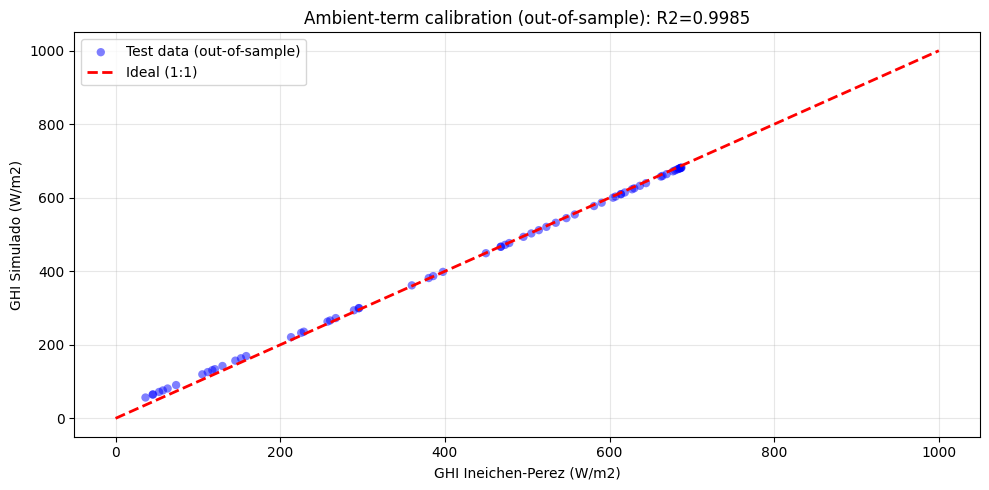

In [7]:
plt.figure(figsize=(10, 5))
plt.scatter(y_true_test, y_pred_test, alpha=0.5, color='blue', edgecolors='none', label='Test data (out-of-sample)')
plt.plot([0, 1000], [0, 1000], 'r--', lw=2, label='Ideal (1:1)')
plt.xlabel("GHI Ineichen-Perez (W/m2)")
plt.ylabel("GHI Simulado (W/m2)")
plt.title(f"Ambient-term calibration (out-of-sample): R2={r2:.4f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()